# COT Positioning — Weekly Exploration

**Purpose:** Load fresh CFTC Commitment of Traders data for all 4 markets, inspect the current positioning landscape, and generate branded charts for X/Substack content.

**Workflow:** Run all cells Sunday before market open. Review the snapshot table and charts, then write your commentary.

**Markets:**
- **NQ** — E-mini Nasdaq 100 (TFF report: Leveraged Money, Asset Managers, Dealers)
- **GC** — Gold (Disaggregated: Managed Money, Swap Dealers, Producers/Merchants)
- **CL** — WTI Crude Oil (Disaggregated)
- **ZC** — Corn (Disaggregated)

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

from src.data.cot import build_cot_dataset
from src.data.config import MARKETS
from src.viz.charts import (
    chart_cot_positioning, chart_cot_overview, chart_cot_momentum
)

%matplotlib inline
pd.set_option('display.float_format', '{:,.0f}'.format)

SYMBOLS = ['NQ', 'GC', 'CL', 'ZC']
print(f"Report date: {date.today().strftime('%B %d, %Y')}")

Report date: March 19, 2026


## 1. Load COT Data

Pull processed COT data from cache. Set `force_refresh=True` on Friday evening after the CFTC release to get the latest week.

In [4]:
FORCE_REFRESH = False  # flip to True after Friday CFTC release

cot = {}
for sym in SYMBOLS:
    cot[sym] = build_cot_dataset(sym, force_refresh=FORCE_REFRESH)
    print(f"{sym}: {len(cot[sym])} weeks | "
          f"{cot[sym].index[0].date()} → {cot[sym].index[-1].date()}")

NQ: 688 weeks | 2013-01-08 → 2026-03-10
GC: 688 weeks | 2013-01-08 → 2026-03-10
CL: 688 weeks | 2013-01-08 → 2026-03-10
ZC: 688 weeks | 2013-01-08 → 2026-03-10


## 2. Positioning Snapshot — Latest Week

The snapshot table gives you the current state at a glance. Key columns:
- **Net** — absolute net contracts (long - short)
- **Z-1yr / Z-3yr** — how extreme is current positioning vs recent history (>2 or <-2 = extreme)
- **26W Index** — 0-100 scale over last 26 weeks (>80 = crowded long, <20 = crowded short)
- **Pctl** — all-time percentile rank
- **WoW Chg** — week-over-week change in net contracts (momentum)

In [6]:
GROUP_MAP = {
    'tff':          ['spec', 'comm', 'asset_mgr'],
    'disaggregated': ['spec', 'comm', 'swap'],
}
GROUP_LABELS = {
    'spec': 'Managed Money', 'comm': 'Commercials',
    'asset_mgr': 'Asset Managers', 'swap': 'Swap Dealers',
}

rows = []
for sym in SYMBOLS:
    df = cot[sym]
    latest = df.iloc[-1]
    report = MARKETS[sym]['cot_report']
    
    for group in GROUP_MAP[report]:
        net = f'{group}_net'
        rows.append({
            'Market': sym,
            'Group': GROUP_LABELS[group],
            'Net': latest[net],
            'WoW Chg': latest[f'{net}_roc'],
            'Z-1yr': latest[f'{net}_z1yr'],
            'Z-3yr': latest[f'{net}_z3yr'],
            '26W Idx': latest[f'{net}_26w'],
            'Pctl': latest[f'{net}_pctl'],
        })

snapshot = pd.DataFrame(rows)
snapshot.style.format({
    'Net': '{:,.0f}', 'WoW Chg': '{:+,.0f}',
    'Z-1yr': '{:+.2f}', 'Z-3yr': '{:+.2f}',
    '26W Idx': '{:.0f}', 'Pctl': '{:.0f}',
}).background_gradient(
    subset=['Z-1yr'], cmap='RdYlGn', vmin=-3, vmax=3
).background_gradient(
    subset=['Z-3yr'], cmap='RdYlGn', vmin=-3, vmax=3
).background_gradient(
    subset=['26W Idx'], cmap='RdYlGn', vmin=0, vmax=100
)

,Market,Group,Net,WoW Chg,Z-1yr,Z-3yr,26W Idx,Pctl
0,NQ,Managed Money,"-22,162","-2,660",-0.36,+0.42,12,33
1,NQ,Commercials,"-40,384","+4,694",+0.64,+0.28,100,47
2,NQ,Asset Managers,"62,464","-4,425",-0.22,-0.38,0,60
3,GC,Managed Money,"102,236","+1,381",-1.12,-0.76,15,48
4,GC,Commercials,"-25,261",+766,+1.91,+1.47,86,91
5,GC,Swap Dealers,"-182,107","-4,323",+0.59,+0.29,64,32
6,CL,Managed Money,"136,419","+27,998",+1.09,+0.05,100,21
7,CL,Commercials,"229,012","+36,619",-0.87,+0.64,50,92
8,CL,Swap Dealers,"-585,216","-90,968",-2.08,-2.47,0,7
9,ZC,Managed Money,"193,271","+140,297",+2.61,+1.73,100,79


## 3. Open Interest Trend

Rising OI with rising price = new money entering (trend confirmation).
Falling OI with rising price = short covering rally (weaker).
Rising OI with falling price = new shorts piling in (bearish conviction).

In [8]:
oi_rows = []
for sym in SYMBOLS:
    df = cot[sym]
    latest = df['open_interest'].iloc[-1]
    prev = df['open_interest'].iloc[-2]
    avg_26w = df['open_interest'].iloc[-26:].mean()
    chg = latest - prev
    chg_pct = (chg / prev) * 100
    vs_avg = ((latest / avg_26w) - 1) * 100
    
    oi_rows.append({
        'Market': sym,
        'OI': latest,
        'WoW Chg': chg,
        'WoW %': chg_pct,
        'vs 26W Avg %': vs_avg,
    })

oi_df = pd.DataFrame(oi_rows)
oi_df.style.format({
    'OI': '{:,.0f}', 'WoW Chg': '{:+,.0f}',
    'WoW %': '{:+.1f}%', 'vs 26W Avg %': '{:+.1f}%',
})

,Market,OI,WoW Chg,WoW %,vs 26W Avg %
0,NQ,"299,569","-12,311",-3.9%,-9.2%
1,GC,"709,862","+9,986",+1.4%,-9.5%
2,CL,"3,138,821","+249,718",+8.6%,+26.1%
3,ZC,"2,219,481","+201,194",+10.0%,+8.9%


## 4. Extreme Detection

Flag any group where z-score exceeds +/- 2 on either the 1-year or 3-year window. These are the setups worth writing about — extreme positioning tends to mean-revert.

In [10]:
extremes = snapshot[
    (snapshot['Z-1yr'].abs() >= 2) | (snapshot['Z-3yr'].abs() >= 2)
].copy()

if len(extremes) > 0:
    print(f"*** {len(extremes)} EXTREME POSITIONING SIGNALS ***\n")
    for _, row in extremes.iterrows():
        direction = "LONG" if row['Z-1yr'] > 0 else "SHORT"
        print(f"  {row['Market']} | {row['Group']} — extreme {direction}")
        print(f"    Z-1yr: {row['Z-1yr']:+.2f}  |  Z-3yr: {row['Z-3yr']:+.2f}  |  Pctl: {row['Pctl']:.0f}")
        print()
else:
    print("No extreme positioning signals this week. All z-scores within +/- 2.")

*** 4 EXTREME POSITIONING SIGNALS ***

  CL | Swap Dealers — extreme SHORT
    Z-1yr: -2.08  |  Z-3yr: -2.47  |  Pctl: 7

  ZC | Managed Money — extreme LONG
    Z-1yr: +2.61  |  Z-3yr: +1.73  |  Pctl: 79

  ZC | Commercials — extreme SHORT
    Z-1yr: -2.50  |  Z-3yr: -1.96  |  Pctl: 16

  ZC | Swap Dealers — extreme LONG
    Z-1yr: +1.93  |  Z-3yr: +2.07  |  Pctl: 97



## 5. Biggest Weekly Moves

Who added or cut the most contracts this week? Large week-over-week changes can signal a positioning shift in progress.

In [12]:
movers = snapshot.copy()
movers['Abs Chg'] = movers['WoW Chg'].abs()
movers = movers.sort_values('Abs Chg', ascending=False)

print("Top weekly movers (by absolute contract change):\n")
for _, row in movers.iterrows():
    direction = "added" if row['WoW Chg'] > 0 else "cut"
    print(f"  {row['Market']:>2} {row['Group']:<16} {direction} {abs(row['WoW Chg']):>8,.0f} contracts  "
          f"(net now: {row['Net']:>+10,.0f})")

Top weekly movers (by absolute contract change):

  ZC Commercials      cut  143,803 contracts  (net now:   -477,414)
  ZC Managed Money    added  140,297 contracts  (net now:   +193,271)
  CL Swap Dealers     cut   90,968 contracts  (net now:   -585,216)
  CL Commercials      added   36,619 contracts  (net now:   +229,012)
  CL Managed Money    added   27,998 contracts  (net now:   +136,419)
  NQ Commercials      added    4,694 contracts  (net now:    -40,384)
  NQ Asset Managers   cut    4,425 contracts  (net now:    +62,464)
  GC Swap Dealers     cut    4,323 contracts  (net now:   -182,107)
  NQ Managed Money    cut    2,660 contracts  (net now:    -22,162)
  GC Managed Money    added    1,381 contracts  (net now:   +102,236)
  ZC Swap Dealers     cut      961 contracts  (net now:   +300,302)
  GC Commercials      added      766 contracts  (net now:    -25,261)


---

## 6. NQ — E-mini Nasdaq 100

TFF report groups: **Leveraged Money** (spec), **Asset Managers**, **Dealers** (comm).

Leveraged Money in NQ tends to be contrarian — they're often wrong at extremes. Asset Managers are the "real money" flow and tend to be more directional.

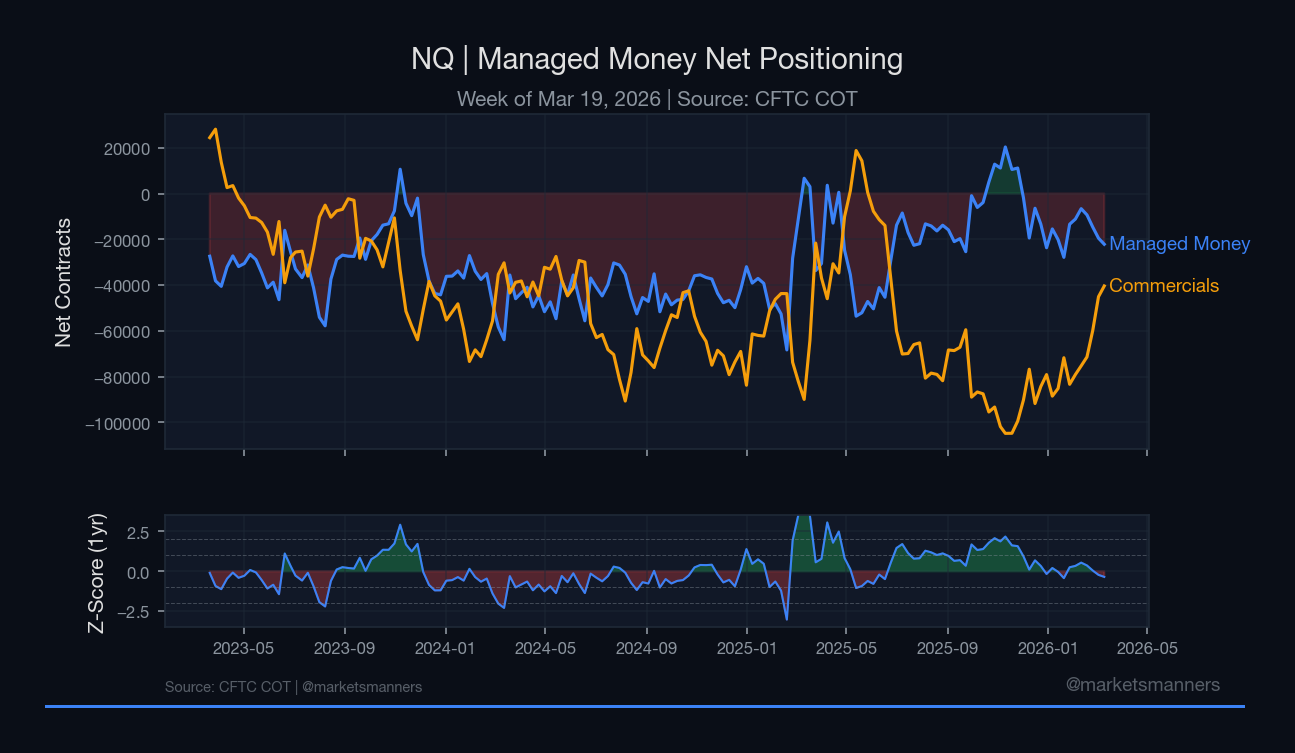

In [14]:
chart_cot_positioning('NQ', save=False)
plt.show()

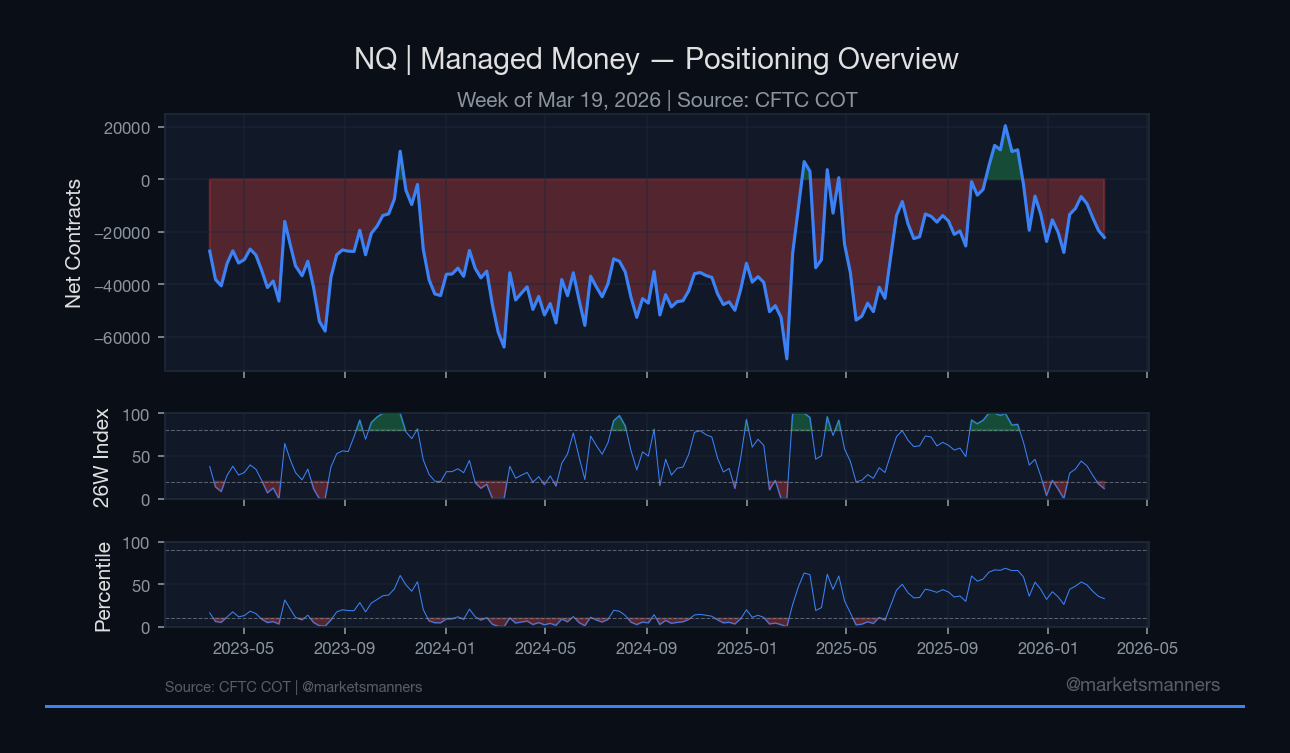

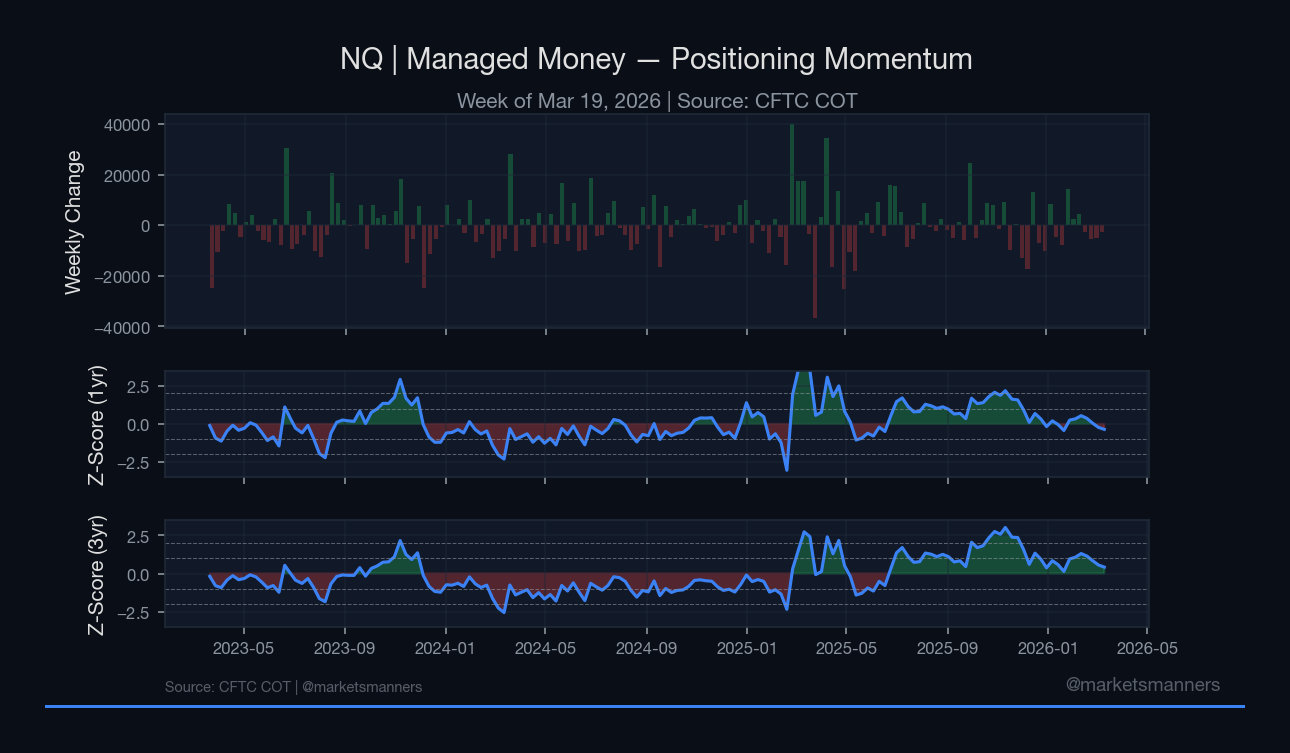

In [15]:
chart_cot_overview('NQ', group='spec', save=False)
plt.show()
chart_cot_momentum('NQ', group='spec', save=False)
plt.show()

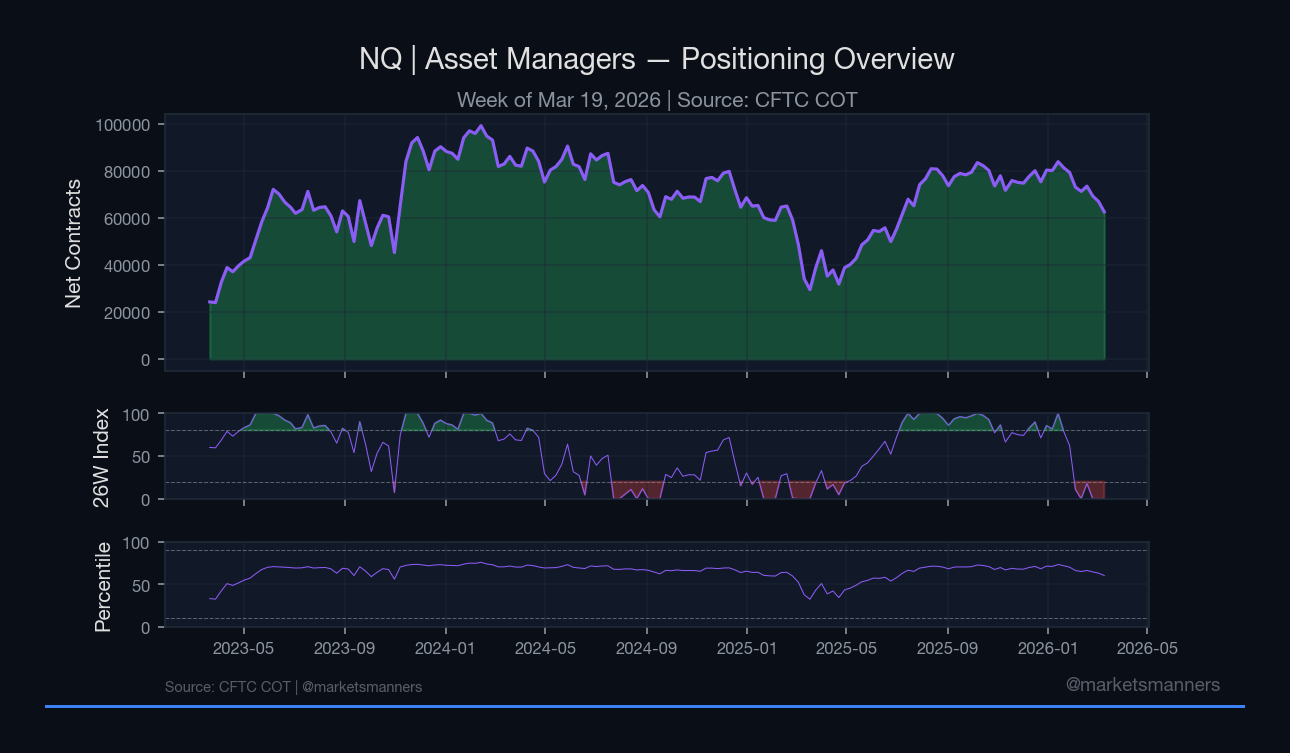

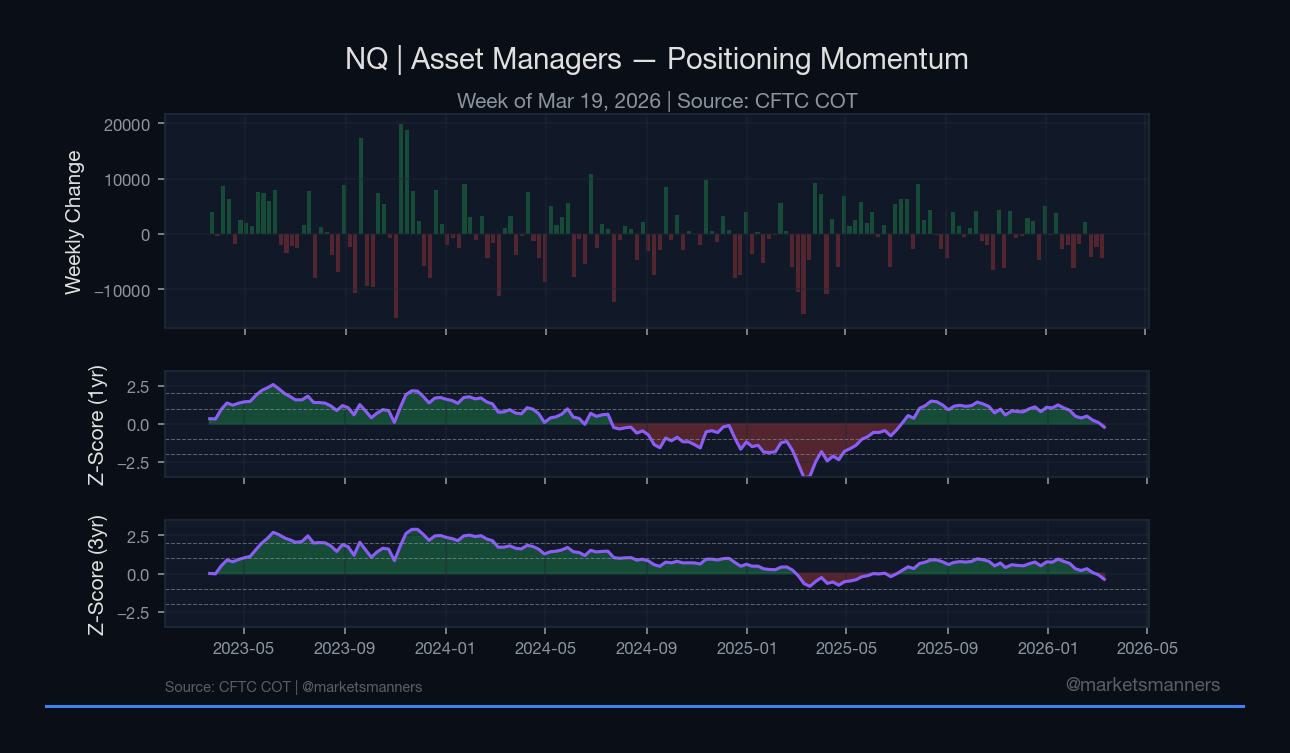

In [16]:
chart_cot_overview('NQ', group='asset_mgr', save=False)
plt.show()
chart_cot_momentum('NQ', group='asset_mgr', save=False)
plt.show()

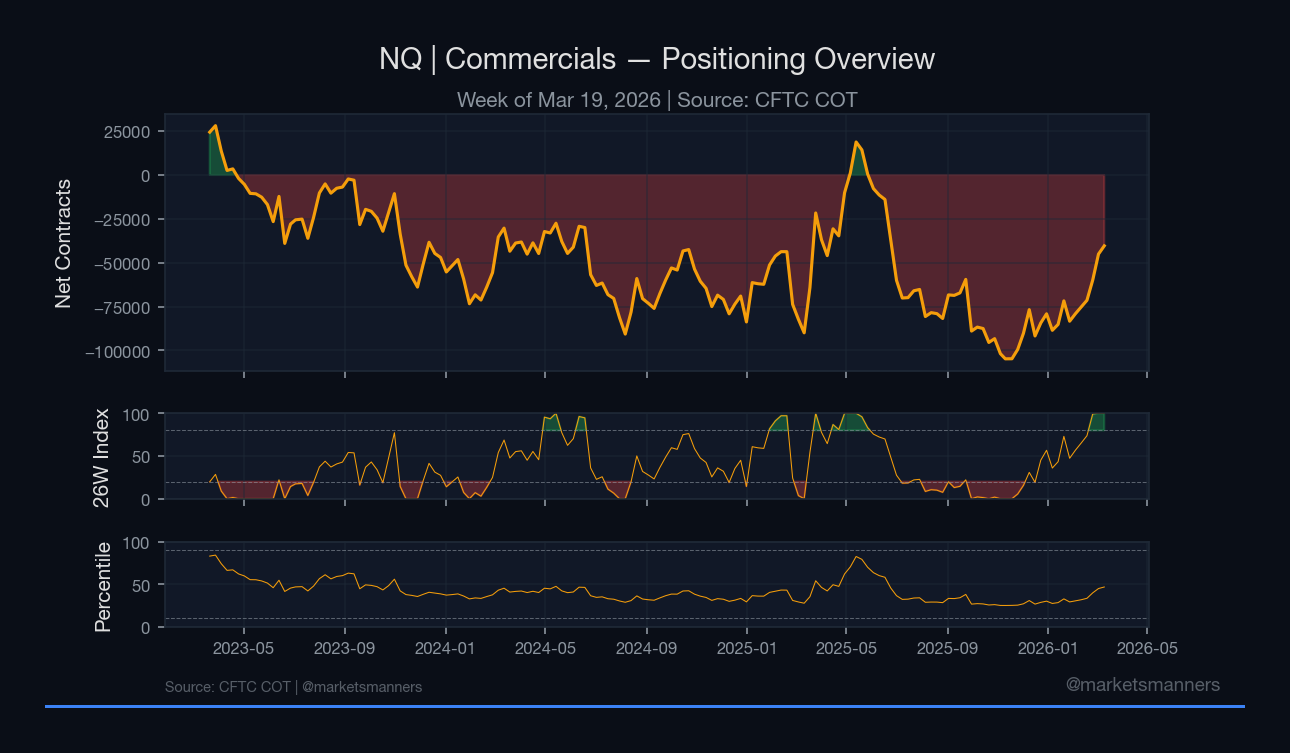

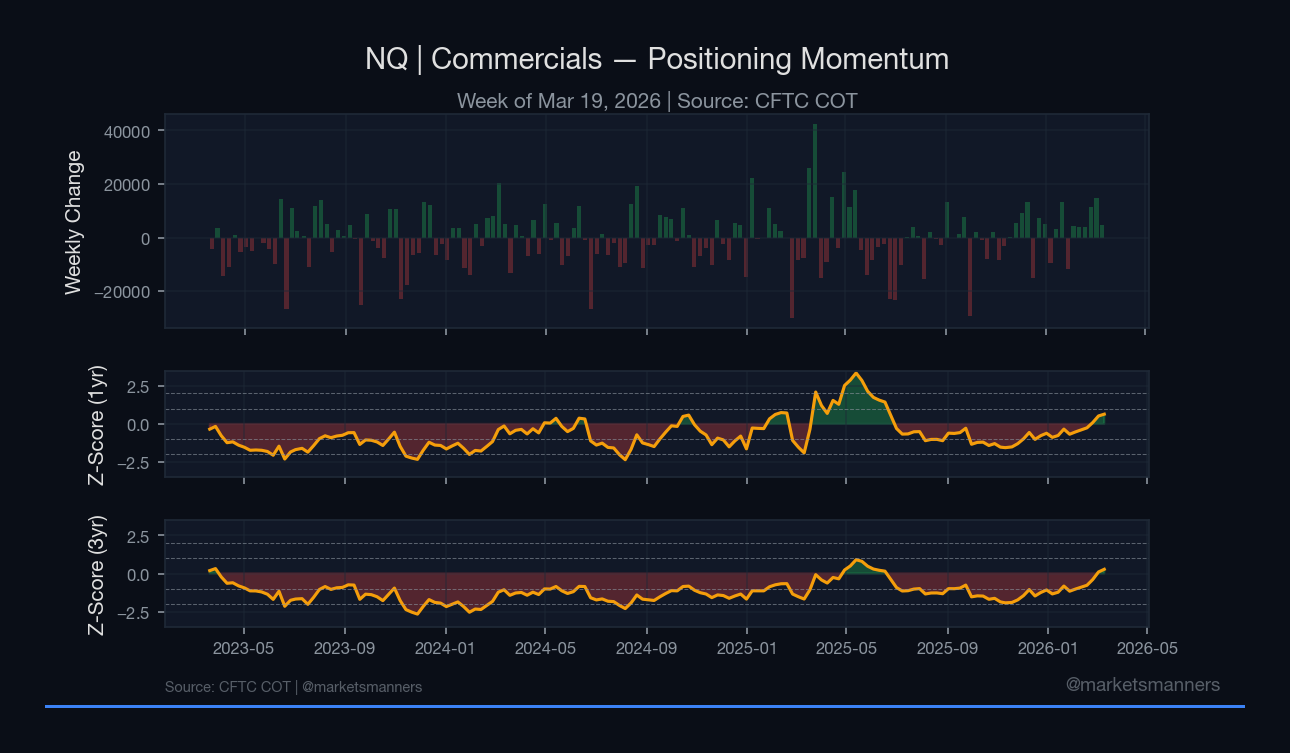

In [17]:
chart_cot_overview('NQ', group='comm', save=False)
plt.show()
chart_cot_momentum('NQ', group='comm', save=False)
plt.show()

**NQ Notes:**

_Write your observations here after reviewing the charts above._

- Managed Money positioning:
- Asset Manager flow:
- Key divergences:
- Content angle for X:

---

## 7. GC — Gold

Disaggregated report: **Managed Money** (spec), **Swap Dealers**, **Producers/Merchants** (comm).

Gold's COT is one of the most reliable contrarian indicators. When Managed Money net longs hit z-score extremes (+2 or higher), gold tends to pull back. When they get washed out (<-2), it tends to rally.

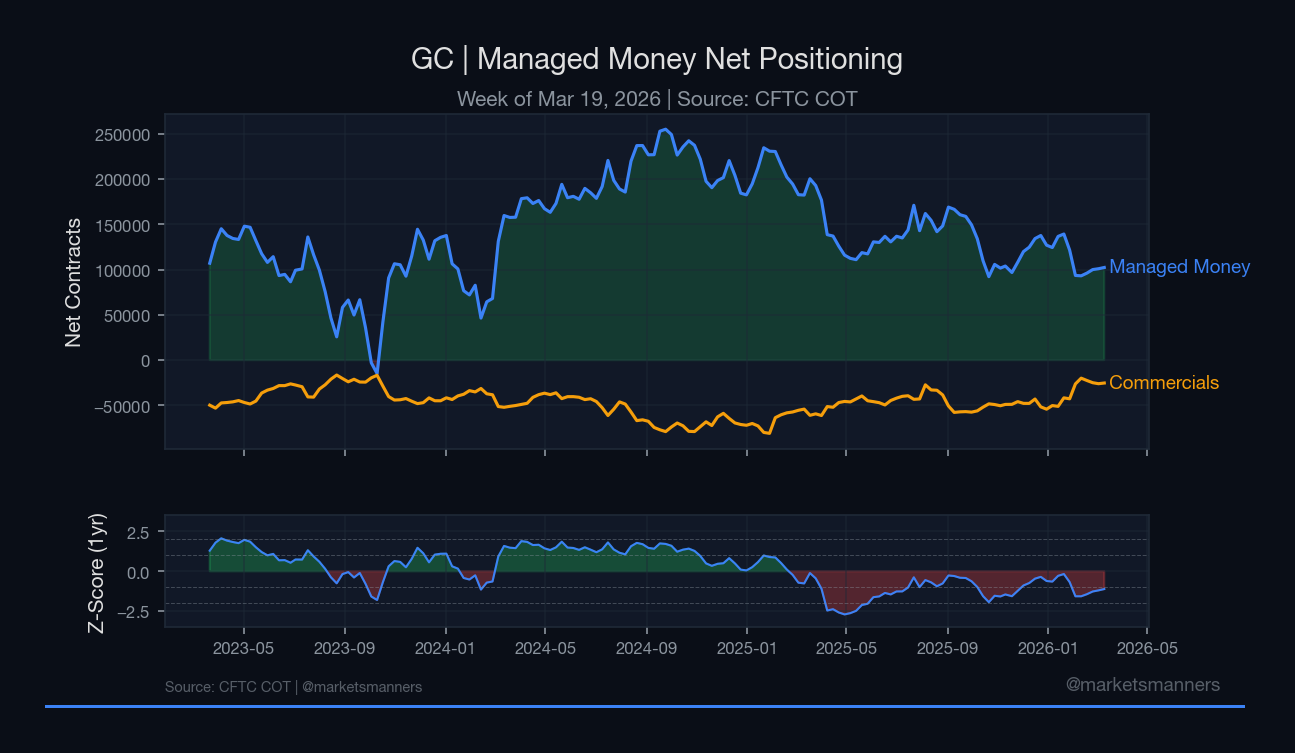

In [19]:
chart_cot_positioning('GC', save=False)
plt.show()

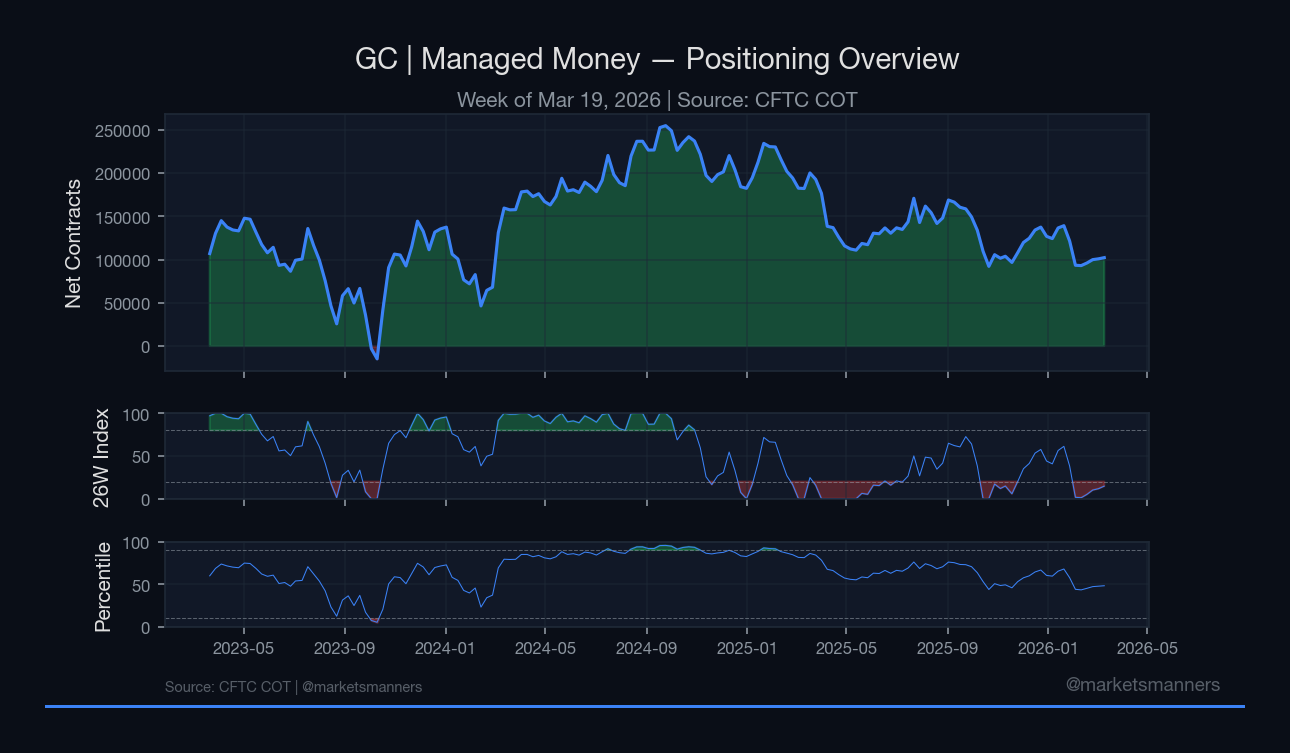

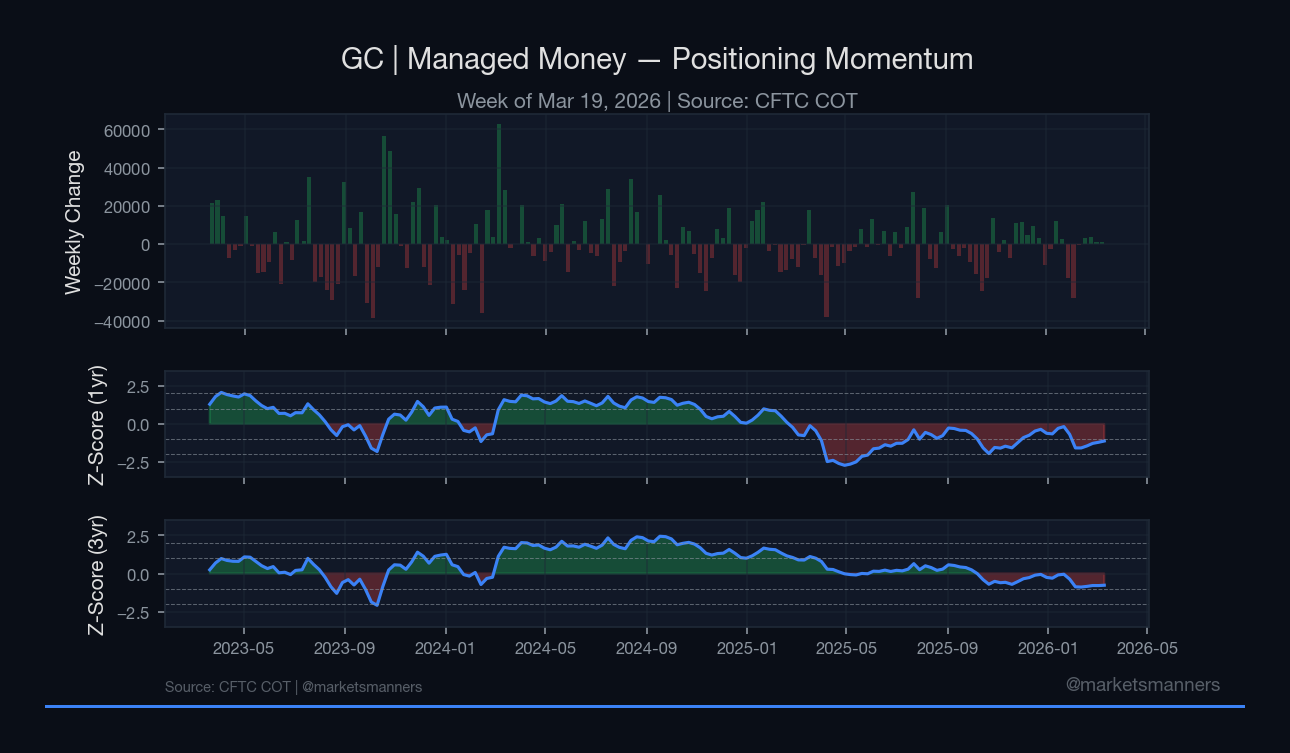

In [20]:
chart_cot_overview('GC', group='spec', save=False)
plt.show()
chart_cot_momentum('GC', group='spec', save=False)
plt.show()

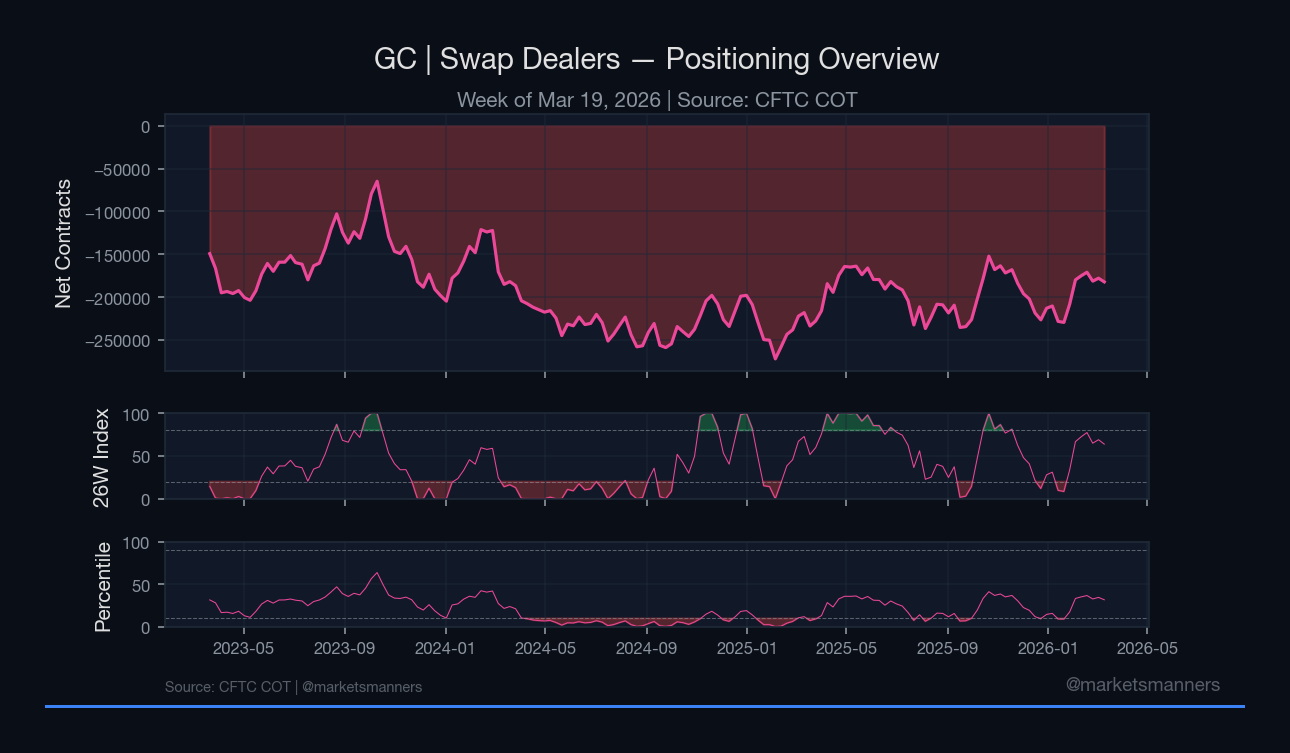

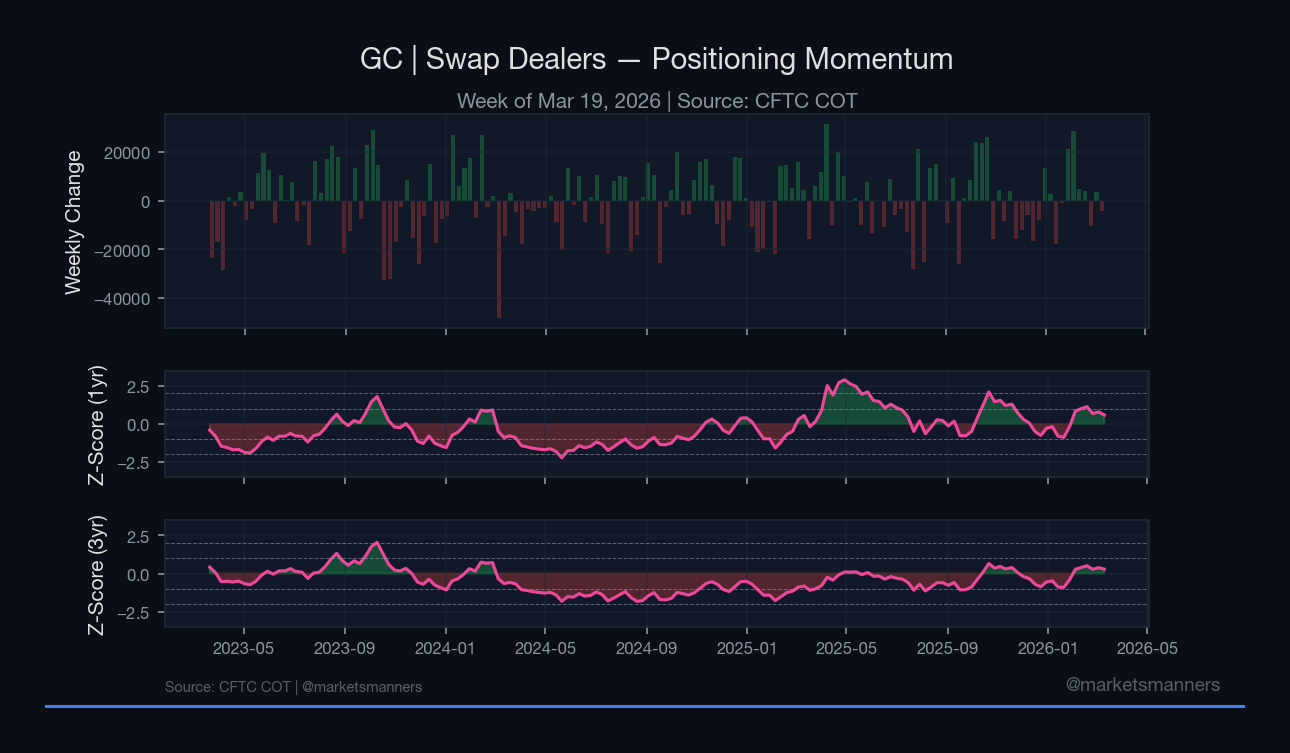

In [21]:
chart_cot_overview('GC', group='swap', save=False)
plt.show()
chart_cot_momentum('GC', group='swap', save=False)
plt.show()

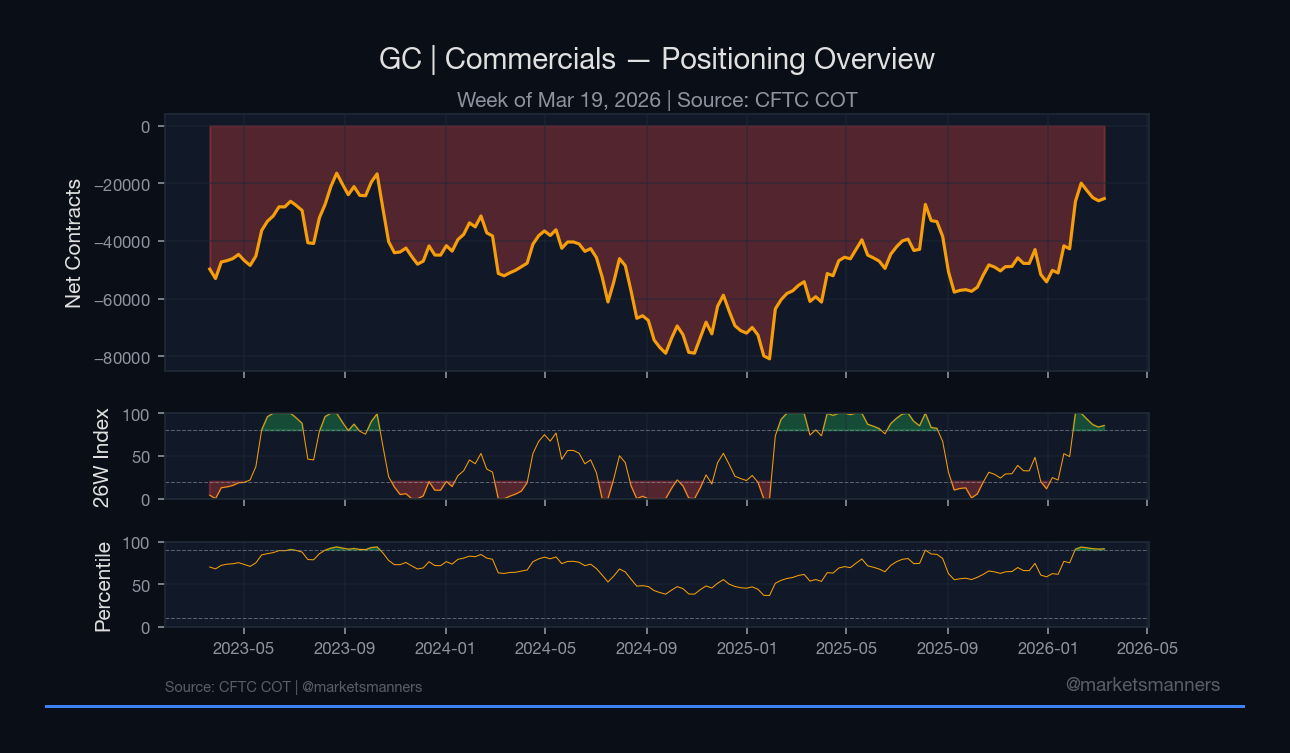

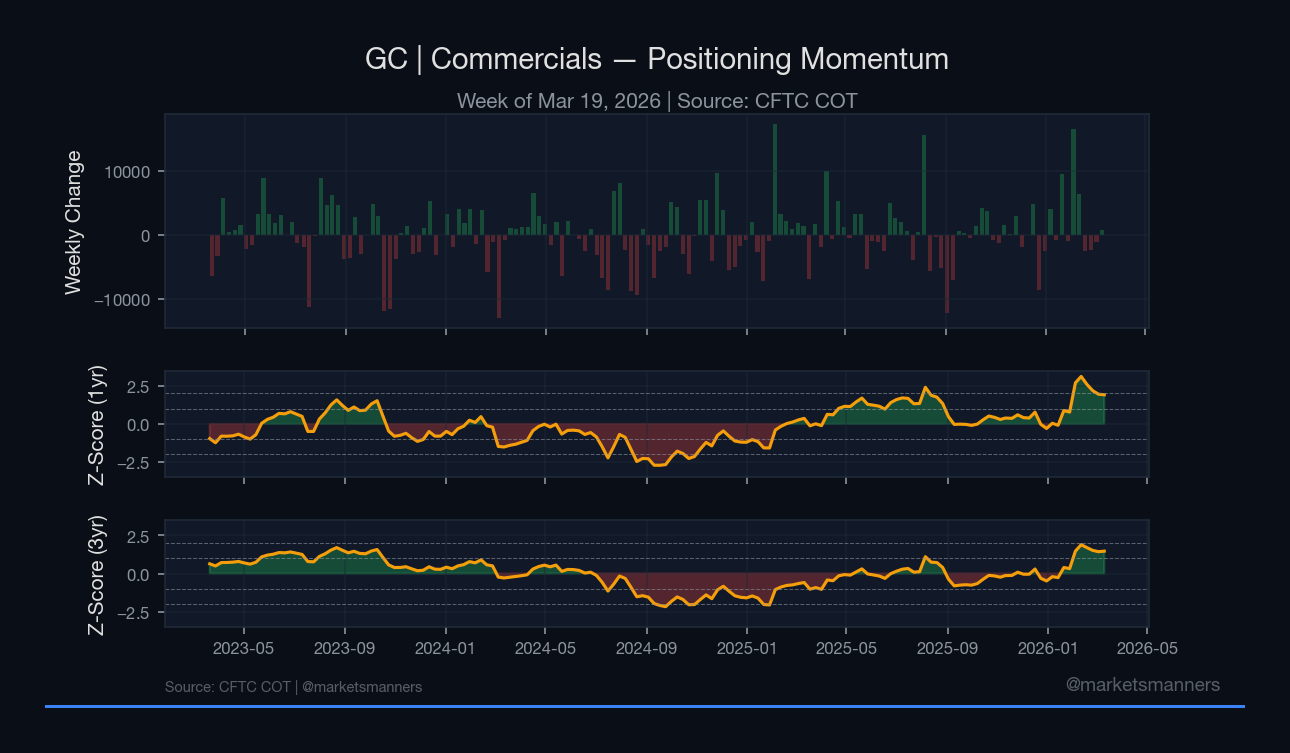

In [22]:
chart_cot_overview('GC', group='comm', save=False)
plt.show()
chart_cot_momentum('GC', group='comm', save=False)
plt.show()

**GC Notes:**

_Write your observations here._

- Managed Money positioning:
- Price/positioning divergence:
- Commercial hedging pressure:
- Content angle for X:

---

## 8. CL — WTI Crude Oil

Disaggregated report: **Managed Money**, **Swap Dealers**, **Producers/Merchants**.

Crude's COT has the widest swings of all 4 markets. Watch for Managed Money net positioning relative to Commercials — when specs and commercials swap extremes, it often marks turning points.

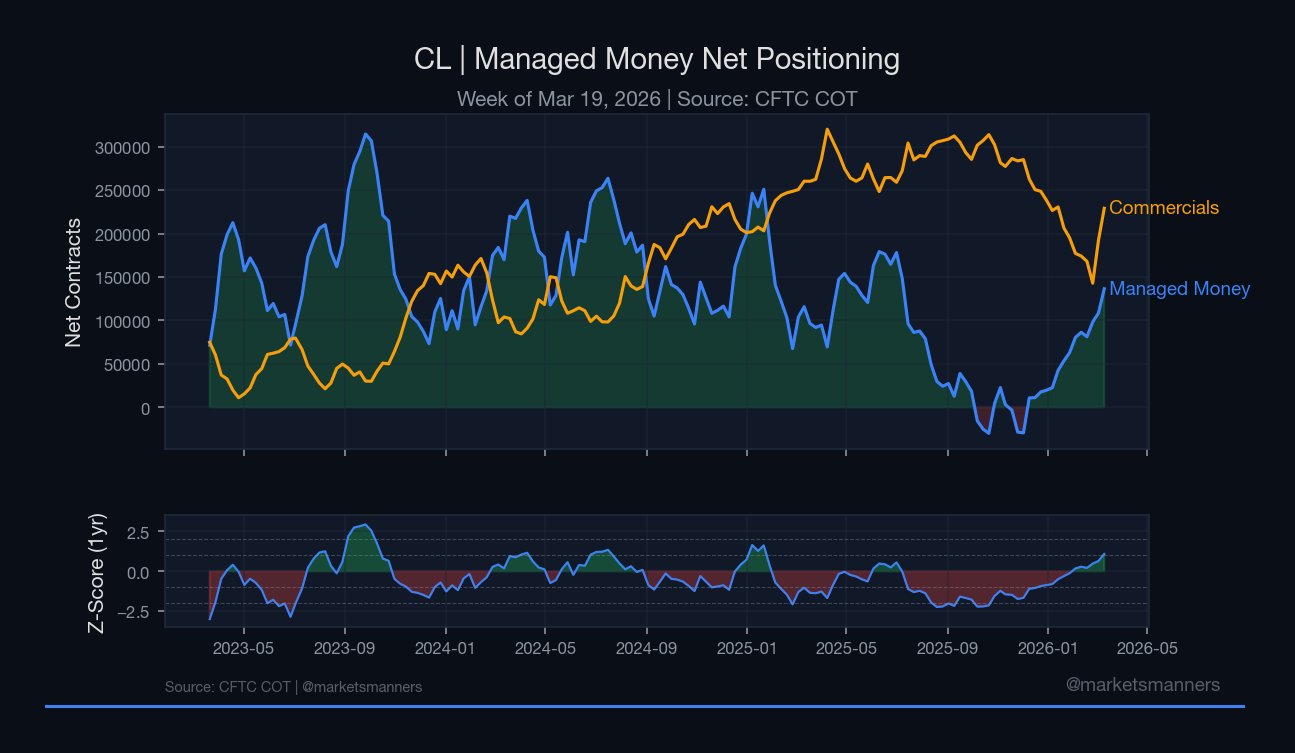

In [24]:
chart_cot_positioning('CL', save=False)
plt.show()

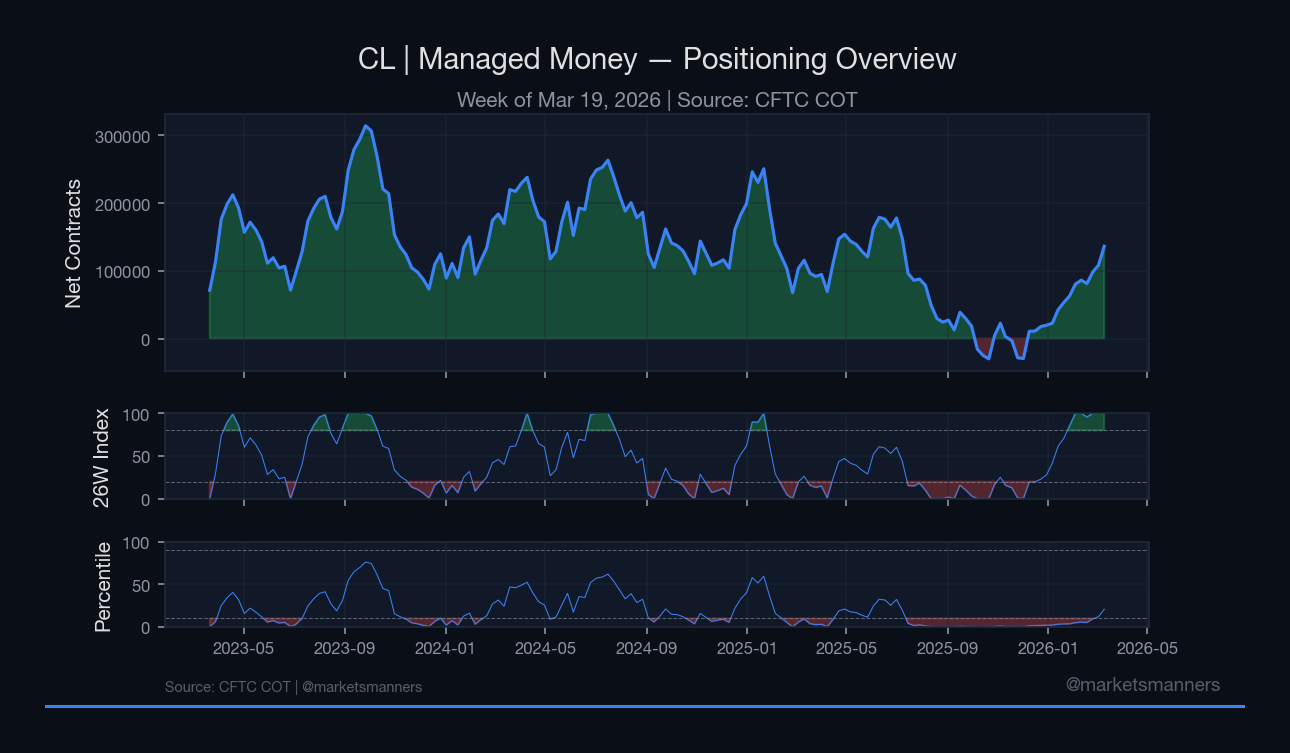

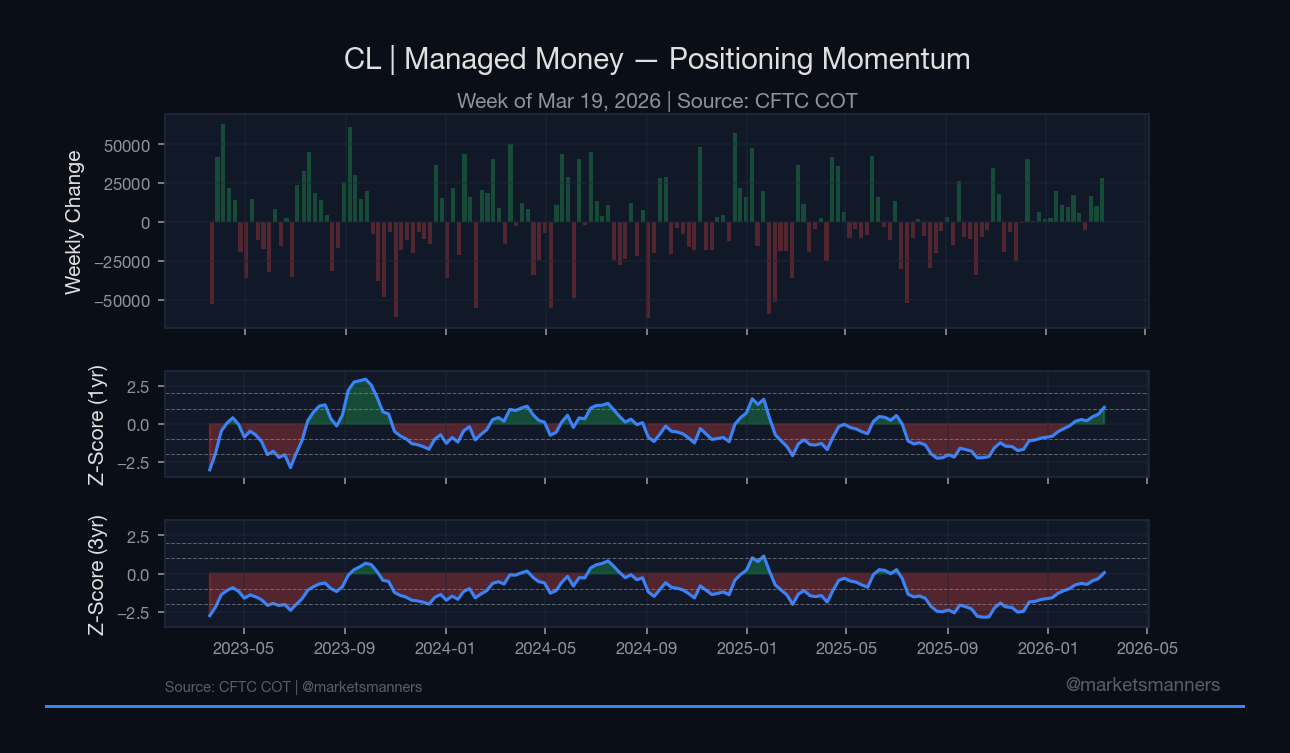

In [25]:
chart_cot_overview('CL', group='spec', save=False)
plt.show()
chart_cot_momentum('CL', group='spec', save=False)
plt.show()

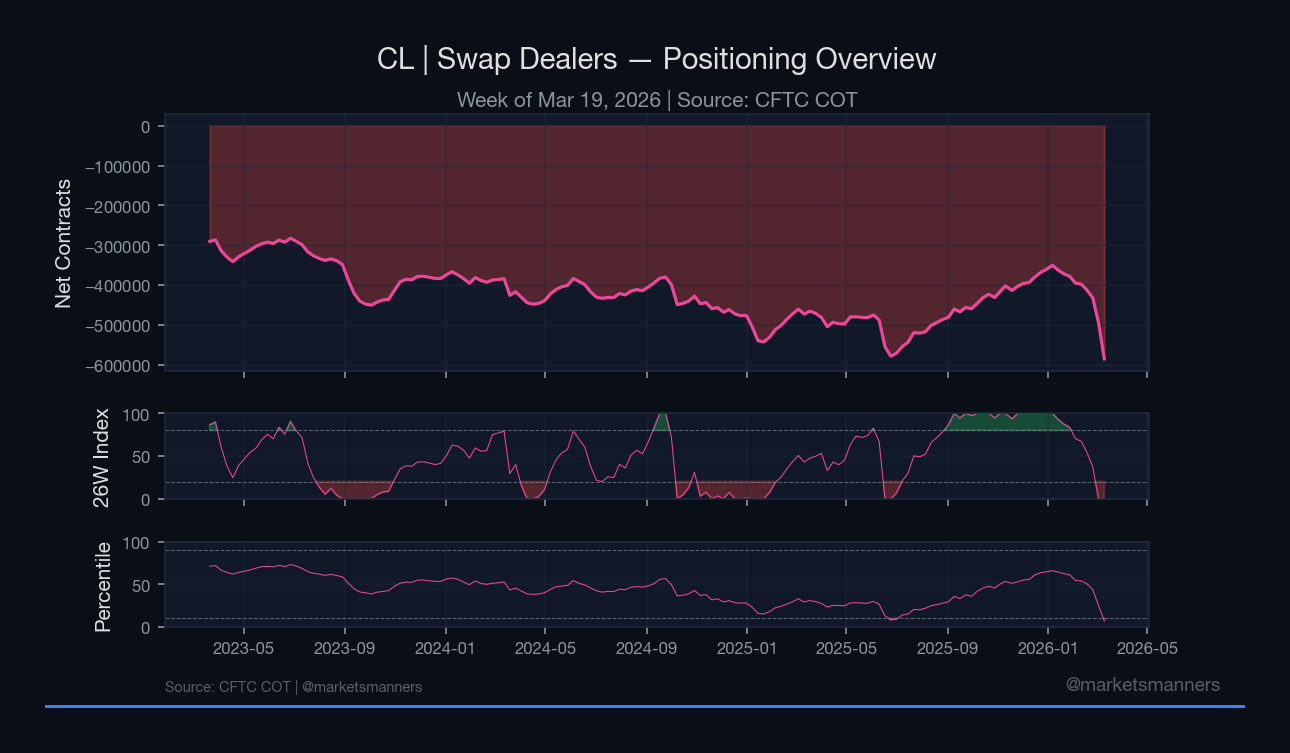

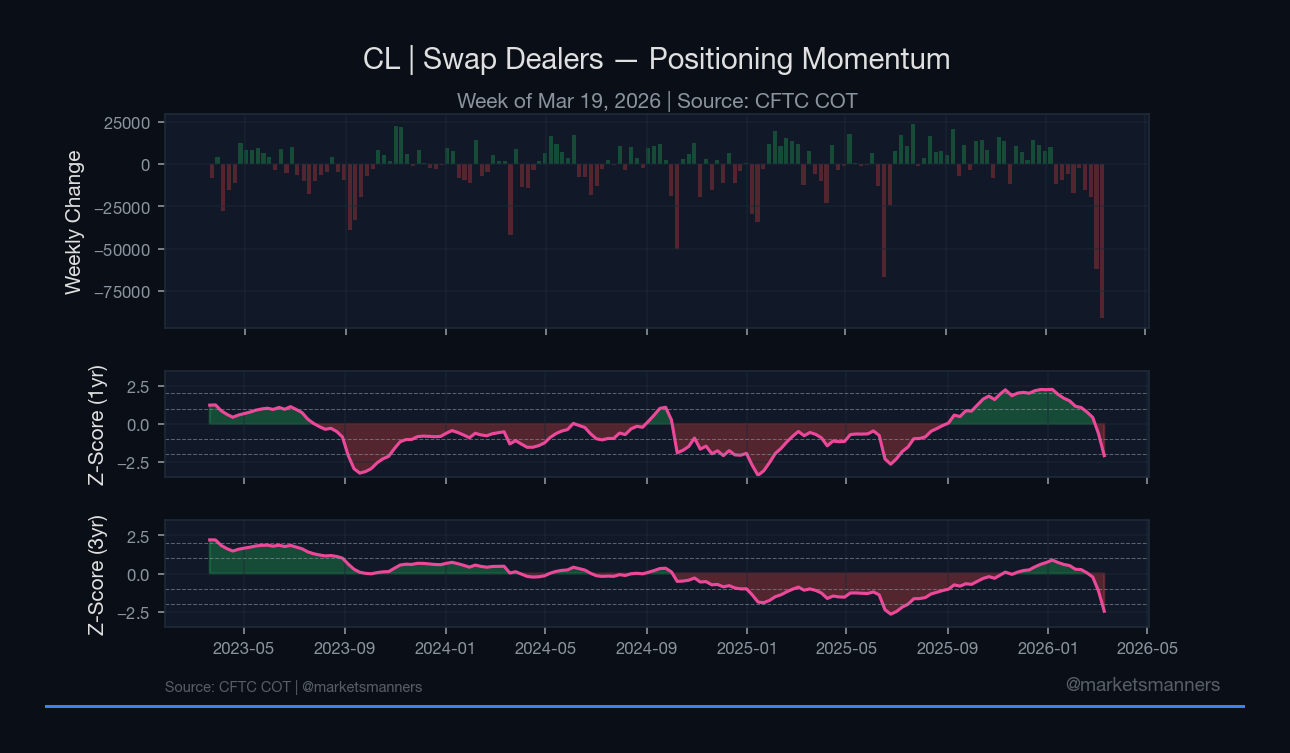

In [26]:
chart_cot_overview('CL', group='swap', save=False)
plt.show()
chart_cot_momentum('CL', group='swap', save=False)
plt.show()

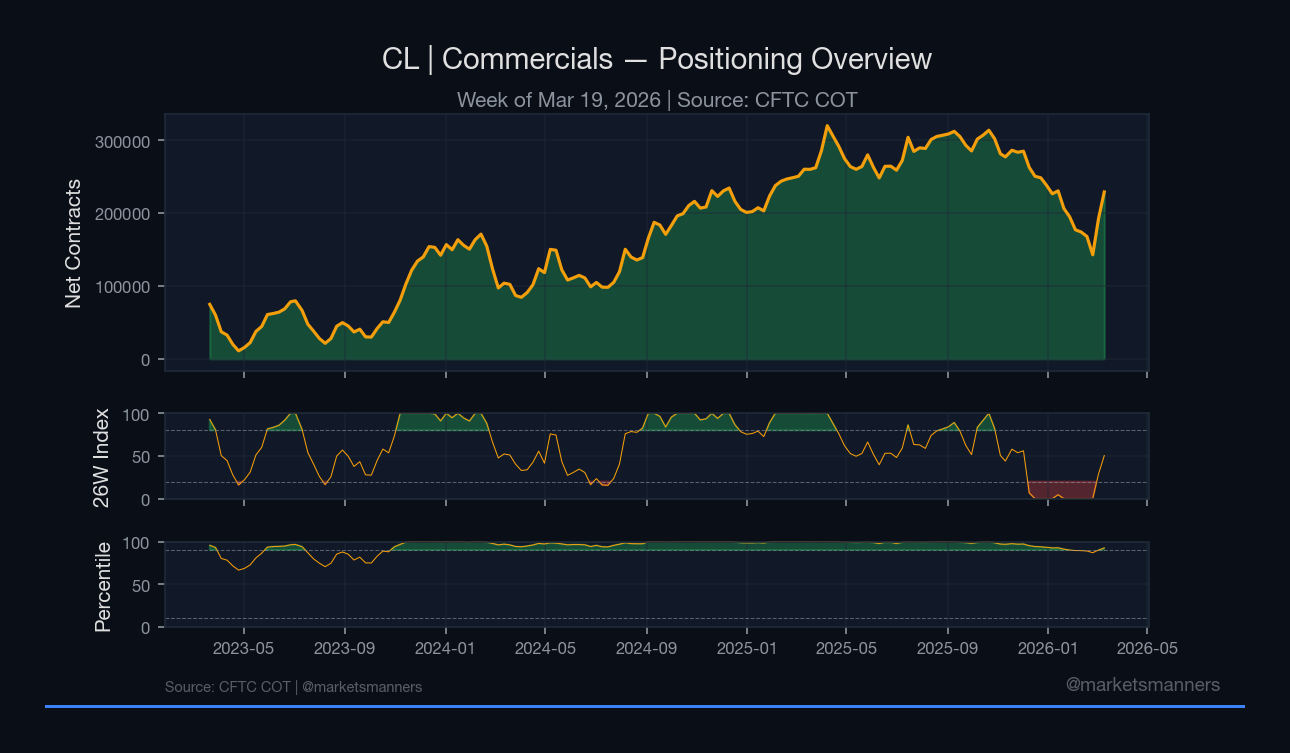

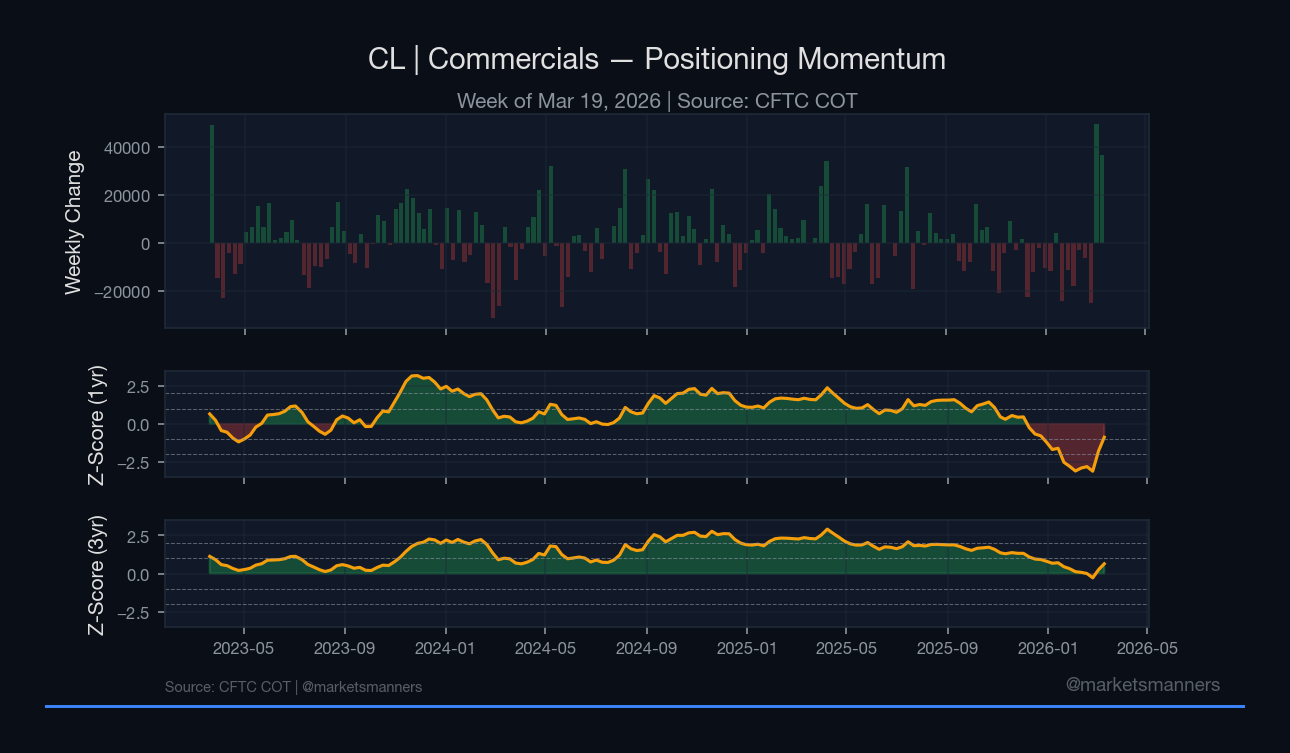

In [27]:
chart_cot_overview('CL', group='comm', save=False)
plt.show()
chart_cot_momentum('CL', group='comm', save=False)
plt.show()

**CL Notes:**

_Write your observations here._

- Managed Money positioning:
- Commercial hedging:
- Supply/demand context:
- Content angle for X:

---

## 9. ZC — Corn

Disaggregated report: **Managed Money**, **Swap Dealers**, **Producers/Merchants**.

Corn has the strongest seasonal patterns of the 4 markets. Commercials (grain elevators, ADM, Cargill) are the "smart money" here — when they hedge heavily, it often precedes moves. Managed Money tends to pile in late and get squeezed.

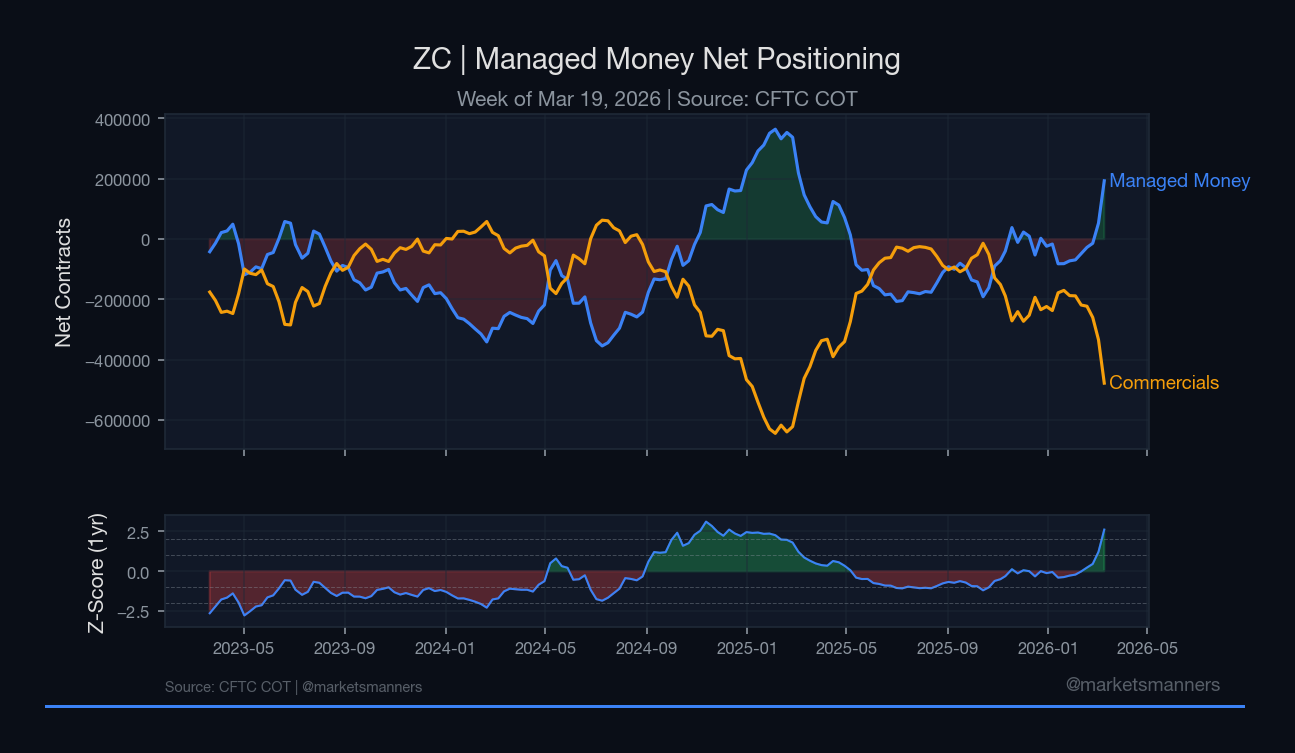

In [29]:
chart_cot_positioning('ZC', save=False)
plt.show()

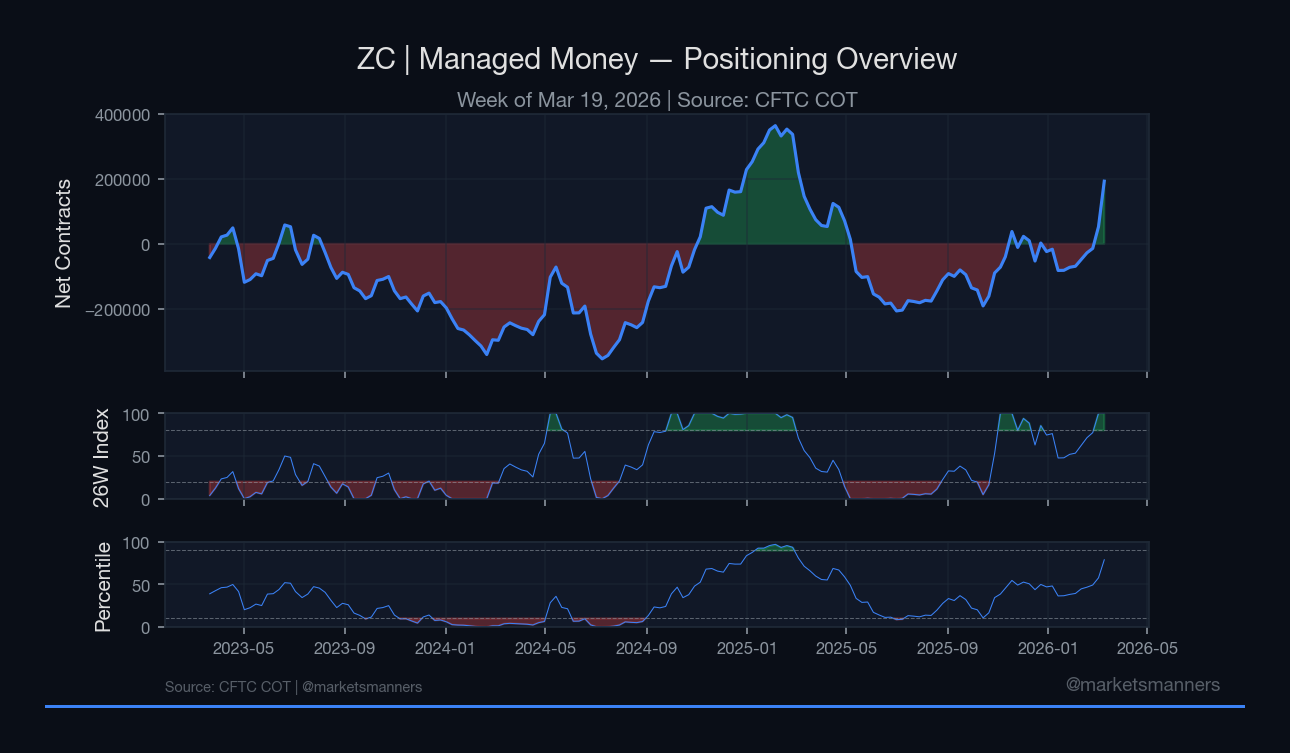

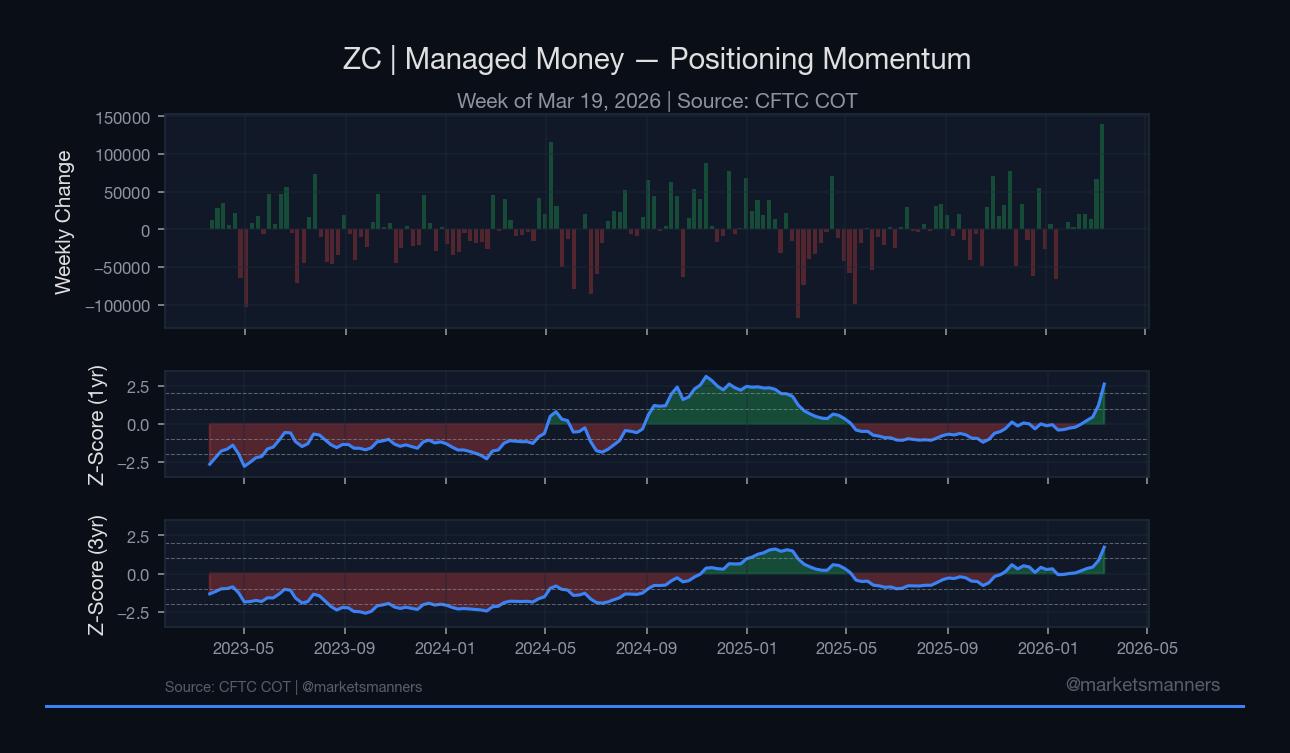

In [30]:
chart_cot_overview('ZC', group='spec', save=False)
plt.show()
chart_cot_momentum('ZC', group='spec', save=False)
plt.show()

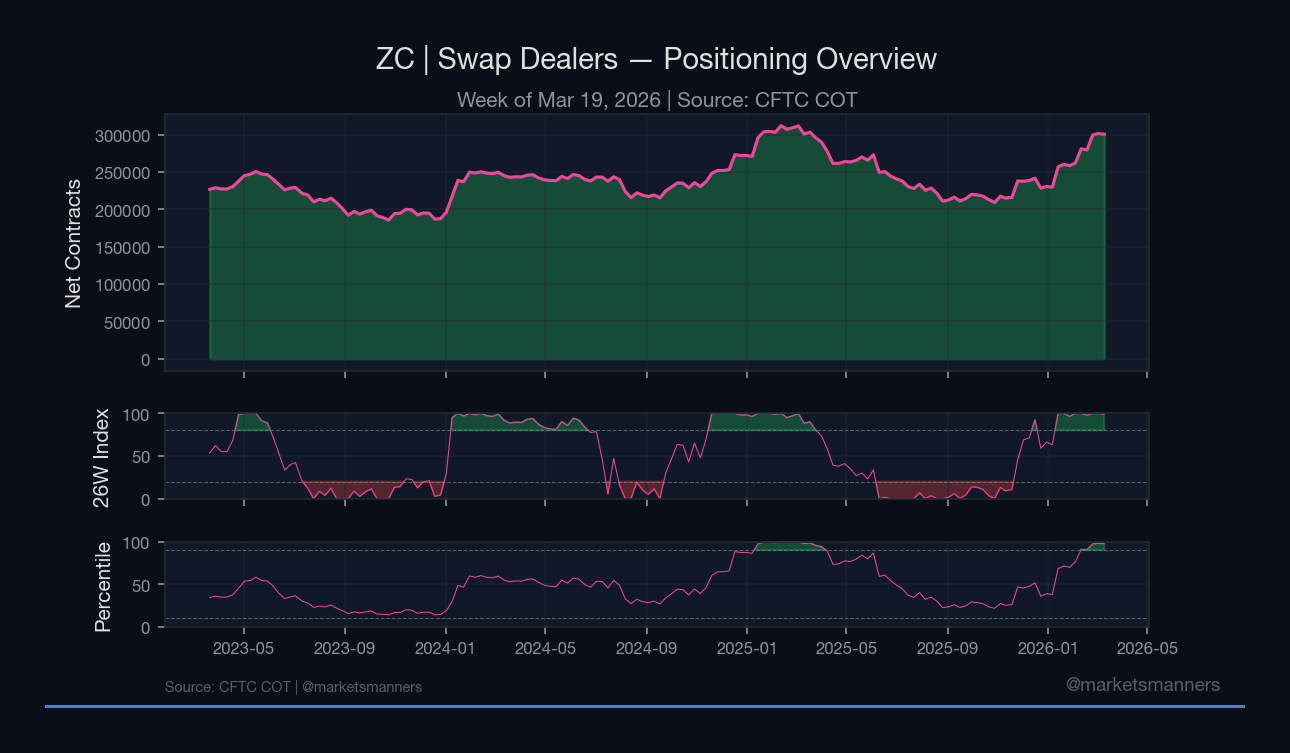

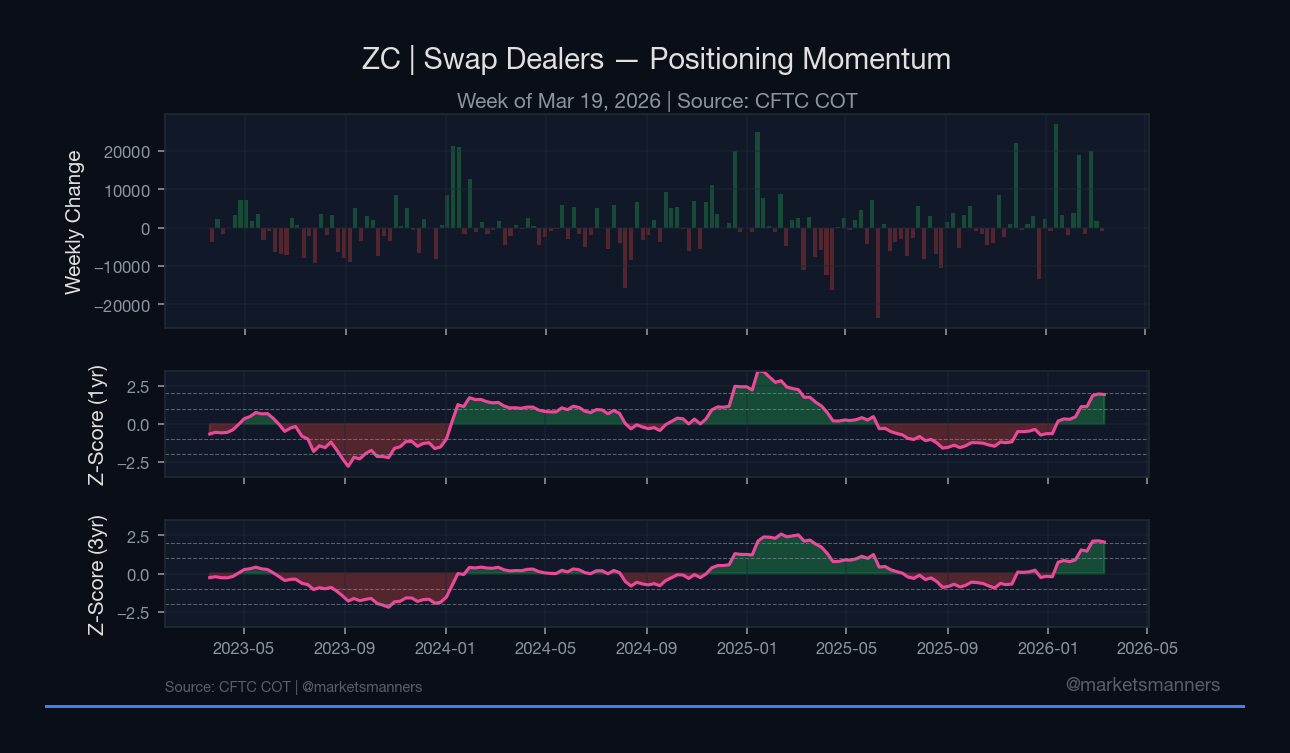

In [31]:
chart_cot_overview('ZC', group='swap', save=False)
plt.show()
chart_cot_momentum('ZC', group='swap', save=False)
plt.show()

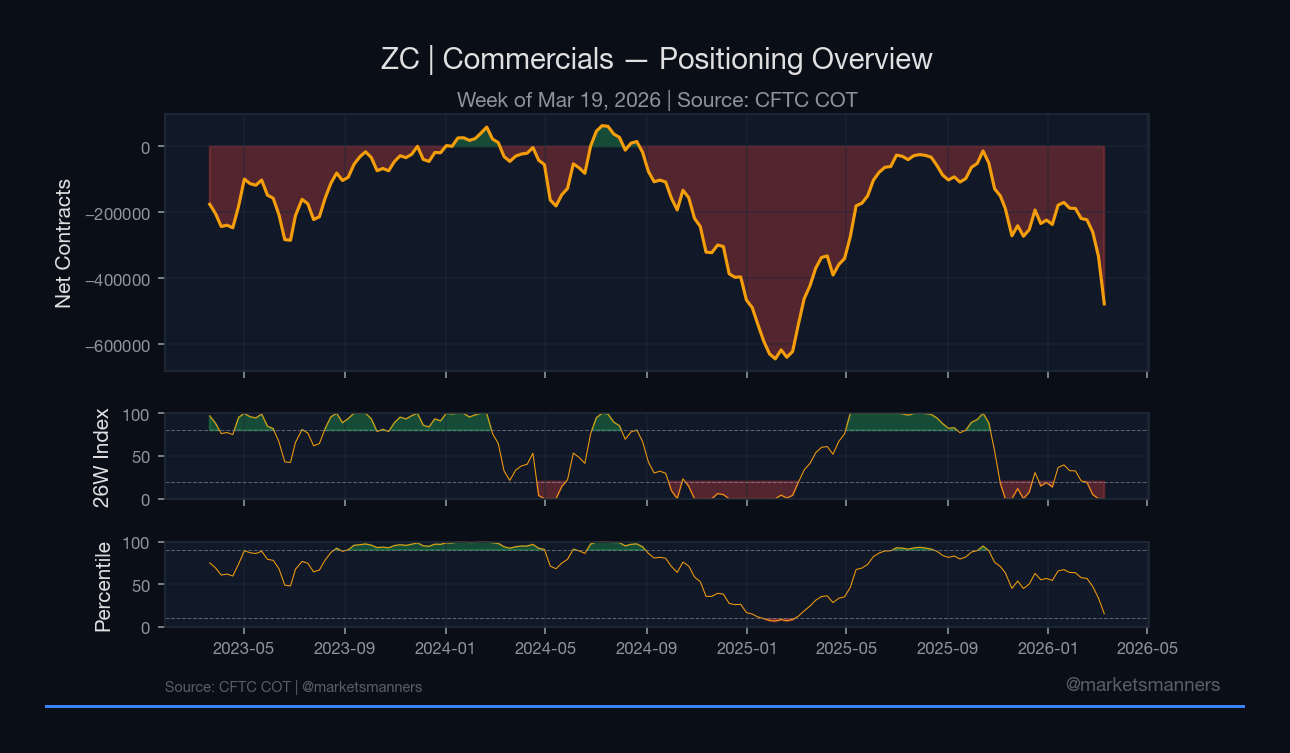

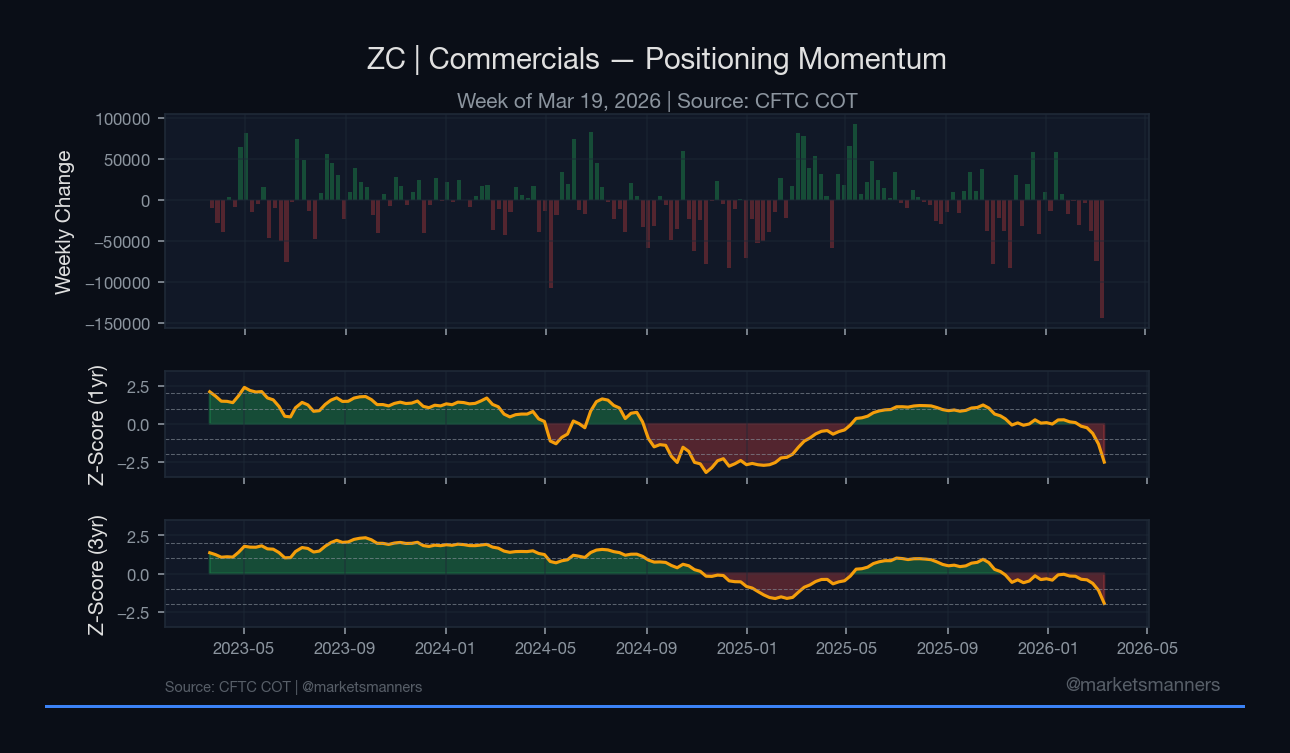

In [32]:
chart_cot_overview('ZC', group='comm', save=False)
plt.show()
chart_cot_momentum('ZC', group='comm', save=False)
plt.show()

**ZC Notes:**

_Write your observations here._

- Managed Money positioning:
- Commercial hedging:
- Seasonal context (planting season approaching?):
- Content angle for X:

---

## 10. Export Charts for X/Substack

Run this cell to save all charts as branded PNGs to `output/charts/`. Pick the best ones for your thread.

In [34]:
from src.viz.charts import chart_cot_all

for sym in SYMBOLS:
    # Main positioning chart
    chart_cot_positioning(sym, save=True)
    # All per-group charts (overview + momentum)
    chart_cot_all(sym, save=True)
    plt.close('all')

print("All COT charts exported to output/charts/")
print(f"Total: {len(SYMBOLS)} positioning + {len(SYMBOLS) * 6} per-group = {len(SYMBOLS) * 7} charts")

All COT charts exported to output/charts/
Total: 4 positioning + 24 per-group = 28 charts
